# STAT201 · 5-hafta · Kompyuter laboratoriyasi (Python)

### Uzluksiz taqsimotlar va normal taqsimot

**Toshkent Xalqaro Universiteti · Iqtisodiyot fakulteti · 2025/2026**

*Davomiyligi: 2 akademik soat (120 daqiqa) · CLO3 · 110 ball $+$ 5 bonus*

> Ushbu daftar `W05-lab-R.Rmd` bilan **belgi-ma-belgi bir xil** matn
> chiqaradi: bir xil maʼlumot, bir xil formatlash, bir xil MINSTD
> generatori (urugʻ 2026). Ikkala daftarning natijasini bevosita
> solishtirish mumkin — bu topshiriqning bir qismi.

---


# Laboratoriya haqida

**Maqsad.** Maʼruzada keltirib chiqarilgan **zichlik funksiyasi**,
**ehtimollik = yuza** tengligi, **normal taqsimot**, **standartlashtirish**
va **normallikni tekshirish** vositalarini haqiqiy maʼlumot ustida
*birinchi tamoyillardan* qurish; soʻng modelning **qayerda ishlashi va
qayerda buzilishini** son bilan aniqlash.

**Haftaning markaziy gʻoyasi — model markazda aʼlo, quyruqda esa notoʻgʻri
boʻlishi mumkin.** Bugun bitta maʼlumot toʻplamiga bitta modelni
qoʻllaymiz. Model taqsimotning oʻrtasida $0{,}6$ protsentil punkti
aniqlikda ishlaydi; $99$-protsentilda esa $151\,\%$ xato beradi. Ikkala
raqam ham bitta modelga tegishli. **Qaror esa deyarli har doim quyruqda
qabul qilinadi.**

> **Qoida.** Normallikni *bitta son* hal qilmaydi. Qiyshiqlik, Q--Q
> korrelyatsiyasi va Shapiro--Wilk testi **bir-biriga zid** javob
> berishi mumkin — va bugun ular aynan shunday qiladi. Grafikni
> koʻrmasdan chiqarilgan xulosa — xulosa emas.

**Ish zanjiri.** Har bir topshiriqda quyidagi ketma-ketlikni yozma
ravishda bajarasiz:

> **statistik tushuncha → maʼlumot → kod → natija → talqin → qaror**

Faqat kod yozib, natijani izohsiz qoldirish — topshiriq bajarilmagan
hisoblanadi. Baholashning yarmidan koʻpi aynan *talqin* va *qaror*
bosqichlariga beriladi.

**Vaqt va ball taqsimoti (120 daqiqa, 110 ball + 5 bonus).**

| # | Mazmun | Daqiqa | Blum | Ball |
|---|---|---|---|---|
| 0 | Muhitni sozlash | 5 | — | — |
| 1 | Zichlik funksiyasi: yigʻindidan integralga | 20 | Qoʻllash | 20 |
| 2 | Normal ehtimolliklar: ikki yoʻnalishda | 20 | Qoʻllash | 20 |
| 3 | Q--Q grafik: bitta son yetarli emas | 25 | Tahlil | 25 |
| 4 | Logarifmik almashtirish: nima yaxshilanadi, nima buziladi | 20 | Baholash | 20 |
| 5 | Binomialning normal yaqinlashishi va uzluksizlik tuzatmasi | 25 | Baholash | 25 |
| 6 | Ixtiyoriy: koʻrsatkichli taqsimot va xotirasizlik | uyda | Yaratish | +5 |

**Oldingi bilim.** Sizga quyidagilar allaqachon maʼlum boʻlishi kerak:
gistogramma va quti diagrammasi (1-hafta); qiyshiqlik va uning ishorasi
(1-hafta); ehtimollik massasi funksiyasi va taqsimot funksiyasi
(4-hafta); binomial va Puasson taqsimotlari, ularning shartlari
(4-hafta); MINSTD generatori va urugʻ tushunchasi (2-hafta).
**MATH102 dan:** aniq integral va uning yuza sifatidagi talqini —
bu hafta u *ishchi asbob*, eslatma emas.

---

# 0-bosqich. Muhitni sozlash

In [1]:
# --- Muhit va versiyalar ----------------------------------------------
# Python UTF-8 ni standart sifatida ishlatadi, shuning uchun R dagi
# LC_CTYPE tuzogʻi bu yerda yoʻq. Ammo QOIDA saqlanadi: toifa nomlarini
# kod ichida literal yozmang — ularni unique() orqali FAYLDAN oling va
# POZITSIYA boʻyicha tanlang. Shunda ikkala daftar bir xil ishlaydi.
import sys, locale
print("python", sys.version.split()[0])
print("stdout kodlashi =", sys.stdout.encoding)

python 3.11.15
stdout kodlashi = UTF-8


In [2]:
# --- Kerakli kutubxonalar ---------------------------------------------
import numpy as np                 # sonli massivlar
import pandas as pd                # jadval koʻrinishidagi maʼlumot
import matplotlib
import matplotlib.pyplot as plt    # grafiklar
from scipy import stats, integrate # taqsimotlar va sonli integrallash

print("pandas", pd.__version__, "| numpy", np.__version__,
      "| scipy", __import__("scipy").__version__)

# Okabe–Ito palitrasi: rang koʻrmaslikka moslashgan.
oiBlue, oiOrange, oiGreen = "#0072B2", "#E69F00", "#009E73"
oiPink, oiVerm,   oiSky   = "#CC79A7", "#D55E00", "#56B4E9"

plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["figure.dpi"]  = 110
plt.rcParams["axes.grid"]   = True
plt.rcParams["grid.alpha"]  = 0.30
# QOIDA (2-haftadan): grafik yorliqlarida faqat ASCII harflar.

# Qisqartmalar: Phi = taqsimot funksiyasi, iPhi = uning teskarisi
Phi, iPhi = stats.norm.cdf, stats.norm.ppf

# --- MANTIQIY QIYMATNI BIR XIL CHOP ETISH -----------------------------
# R «TRUE», Python esa «True» yozadi. Ikkala daftar matni belgi-ma-belgi
# bir xil boʻlishi uchun mantiqiy qiymatni OʻZIMIZ formatlaymiz.
def tf(b): return "TRUE" if bool(b) else "FALSE"

%matplotlib inline

pandas 3.0.2 | numpy 2.4.4 | scipy 1.17.1


In [3]:
# --- Ikkita haqiqiy maʼlumot toʻplami ---------------------------------
# A. kinolar-byudjet.csv — 2 467 film (2000–2018), byudjet AQSh dollarida.
# B. markaziy-osiyo-hosildorlik.csv — 5 mamlakat x 27 yil (1992–2018),
#    hosildorlik t/ga. Manba: FAOSTAT / Our World in Data.
kino  = pd.read_csv("data/kinolar-byudjet.csv", encoding="utf-8")
hosil = pd.read_csv("data/markaziy-osiyo-hosildorlik.csv", encoding="utf-8")

byudjet     = kino["byudjet"].to_numpy()/1e6    # mln $ — oʻqish qulay boʻlsin
mamlakatlar = hosil["mamlakat"].unique()        # POZITSIYA boʻyicha ishlatamiz

print("kinolar          : n = %d   (%d-%d)" % (len(kino), kino.yil.min(), kino.yil.max()))
print("byudjet oraligi  : %.2f - %.2f mln $" % (byudjet.min(), byudjet.max()))
print("hosildorlik      : %d qator = %d mamlakat x %d yil"
      % (len(hosil), len(mamlakatlar), len(hosil)//len(mamlakatlar)))
for i, m in enumerate(mamlakatlar, 1):
    print("  [%d] %s" % (i, m))

kinolar          : n = 2467   (2000-2018)
byudjet oraligi  : 0.25 - 175.00 mln $
hosildorlik      : 135 qator = 5 mamlakat x 27 yil
  [1] Oʻzbekiston
  [2] Qirgʻiziston
  [3] Qozogʻiston
  [4] Tojikiston
  [5] Turkmaniston


> **Toʻplamning chegarasi — darhol yozib qoʻying.** Byudjetlar
> $0{,}25$ dan $175$ mln \$ gacha. Toʻplamda $175$ mln \$ dan qimmat film
> **yoʻq**. Bu — toʻplam qanday yigʻilganining xossasi, kinosanoatning
> emas. 4-topshiriqda bu chegara modelning quyruqdagi xatosini
> tushuntirishda hal qiluvchi rol oʻynaydi.

---

# 1-topshiriq. Zichlik funksiyasi: yigʻindidan integralga

**Qiyinlik: 3 (Amaliy) · Blum: Qoʻllash · 20 ball · 20 daqiqa**

### Statistik tushuncha

Diskret holda ehtimollik **massa**da toʻplangan edi: $p(x)=\Pr(X=x)$ va
$\sum_x p(x)=1$. Uzluksiz holda alohida nuqtaning ehtimoli **nol**, shu
sababli massa emas, **zichlik** ishlatiladi.

**Zichlik funksiyasi** *(probability density function)* — shunday
$f(x)\ge 0$ funksiyaki,
$$\Pr(a<X<b)=\int_a^b f(x)\,dx, \qquad \int_{-\infty}^{\infty} f(x)\,dx=1 .$$

Ikkala shart ham **tekshiriladi**, xuddi diskret holdagi kabi. Faqat
yigʻindi $\sum$ oʻrnini integral $\int$ egallaydi.

**Uchta natija bevosita kelib chiqadi:**

1. $\Pr(X=x)=\int_x^x f=0$ — har qanday alohida nuqtaning ehtimoli nol;
2. shu sababli $\Pr(X<a)=\Pr(X\le a)$ — uzluksiz holda qatʼiy va
   qatʼiy boʻlmagan tengsizlik **farq qilmaydi** (diskret holda farq
   qilardi: 4-haftada farq $p(4)=0{,}2370$ edi);
3. $f(x)$ — **ehtimollik emas**. U $1$ dan katta boʻlishi ham mumkin.
   $f(x)$ — ehtimollikning *zichligi*, yaʼni $\Pr(x-\delta<X<x+\delta)
   \approx f(x)\cdot 2\delta$.

**Tekis taqsimot** $X\sim\Unif(a,b)$: $f(x)=1/(b-a)$, $a\le x\le b$.
Bu — yagona zichlik funksiyasiki, uni qoʻlda toʻliq hisoblash mumkin,
shuning uchun undan boshlaymiz.

### Maʼlumot

Birinchi qism — faraziy $\Unif(10,25)$ (masalan, kutish vaqti daqiqada).
Ikkinchi qism — haqiqiy: `kinolar-byudjet.csv` dan olingan
$\ln(\text{byudjet})$ va unga moslangan normal model.

In [4]:
# --- 1-qadam: tekis taqsimot — hamma narsa qoʻlda hisoblanadi ----------
a, b = 10, 25
f_unif = lambda x: np.where((np.asarray(x) >= a) & (np.asarray(x) <= b), 1/(b-a), 0.0)

print("f(x)       = 1/(b-a)      = %.6f" % (1/(b-a)))
print("E[X]       = (a+b)/2      = %.4f" % ((a+b)/2))
print("Var(X)     = (b-a)^2/12   = %.4f" % ((b-a)**2/12))
print("SD(X)      = sqrt(Var)    = %.4f" % np.sqrt((b-a)**2/12))
print("P(12<X<18) = (18-12)/(b-a)= %.6f" % (6/(b-a)))
print("F(18)      = (18-a)/(b-a) = %.6f" % ((18-a)/(b-a)))
print("P(X=15)    = 0            = %.6f" % 0)

# Ikkinchi shartni SONLI tekshiramiz: integral aynan 1 mi?
I_unif = integrate.quad(f_unif, a, b)[0]
print("integral f = %.10f" % I_unif)
print("|integral - 1| < 1e-10   : %s" % tf(abs(I_unif-1) < 1e-10))

f(x)       = 1/(b-a)      = 0.066667
E[X]       = (a+b)/2      = 17.5000
Var(X)     = (b-a)^2/12   = 18.7500
SD(X)      = sqrt(Var)    = 4.3301
P(12<X<18) = (18-12)/(b-a)= 0.400000
F(18)      = (18-a)/(b-a) = 0.533333
P(X=15)    = 0            = 0.000000
integral f = 1.0000000000
|integral - 1| < 1e-10   : TRUE


In [5]:
# --- 2-qadam: normal zichlikni QOʻLDA yozamiz --------------------------
# Parametrlarni HAQIQIY maʼlumotdan olamiz: ln(byudjet) ning oʻrtachasi
# va standart ogʻishi. Shu bilan model «kitobdagi misol» emas, shu
# maʼlumotga moslangan model boʻladi.
ln_b = np.log(byudjet)
mu, sig = ln_b.mean(), ln_b.std(ddof=1)     # ddof=1 -> maxraj n-1
print("\nln(byudjet): mu = %.6f   sigma = %.6f" % (mu, sig))

# f(x) = 1/(sigma sqrt(2 pi)) exp(-(x-mu)^2 / (2 sigma^2))
f_norm = lambda x: (1/(sig*np.sqrt(2*np.pi)))*np.exp(-0.5*((np.asarray(x)-mu)/sig)**2)

# Nazorat: scipy ning norm.pdf() funksiyasi bilan solishtiramiz.
xt = np.linspace(mu-4*sig, mu+4*sig, 9)
print("maks |qolda - dnorm| < 1e-15 : %s"
      % tf(np.abs(f_norm(xt)-stats.norm.pdf(xt, mu, sig)).max() < 1e-15))
# BIRINCHI SHART: f(x) >= 0 hamma joyda
print("barcha f(x) >= 0             : %s"
      % tf(np.all(f_norm(np.arange(-10, 15.0001, 0.01)) >= 0)))


ln(byudjet): mu = 2.938942   sigma = 1.314131
maks |qolda - dnorm| < 1e-15 : TRUE
barcha f(x) >= 0             : TRUE


In [6]:
# --- 3-qadam: IKKINCHI SHART ikki usulda ------------------------------
# (i) PANJARA (Riman yigʻindisi) — integralning taʼrifi boʻyicha:
#     oraliqni n boʻlakka boʻlamiz, har birida f ni bitta nuqtada
#     hisoblaymiz va kenglikka koʻpaytiramiz. Bu — «yigʻindidan
#     integralga» oʻtishning aynan oʻzi.
lo, hi = mu-6*sig, mu+6*sig
def o_nuqta(n):                       # oʻrta nuqta usuli
    h = (hi-lo)/n; xs = lo+np.arange(n)*h+h/2
    return f_norm(xs).sum()*h
def trapets(n):                       # trapetsiya usuli
    h = (hi-lo)/n; xs = lo+np.arange(n+1)*h
    w = np.ones(n+1); w[0] = 0.5; w[n] = 0.5
    return (w*f_norm(xs)).sum()*h
aniq = Phi(hi, mu, sig)-Phi(lo, mu, sig)
print("\naniq qiymat Phi(6)-Phi(-6)   = %.10f" % aniq)
print("%8s %14s %14s %14s %14s"
      % ("n","qadam h","orta nuqta","trapetsiya","|orta - aniq|"))
for n in (10, 100, 1000, 10000):
    e = abs(o_nuqta(n)-aniq)
    print("%8d %14.8f %14.10f %14.10f %14s"
          % (n, (hi-lo)/n, o_nuqta(n), trapets(n),
             "< 1e-13" if e < 1e-13 else "%.3e" % e))
# (ii) TAYYOR SONLI INTEGRALLASH — butun sonlar oʻqi boʻyicha.
# DIQQAT: R ning integrate() va Pythonning quad() funksiyalari oxirgi
# raqamlarda farq qilishi mumkin, shuning uchun natijani SON sifatida
# emas, DOPUSK sifatida chop etamiz (4-haftadagi qoida).
I_norm = integrate.quad(f_norm, -np.inf, np.inf)[0]
print("integrate(-Inf, Inf): |I - 1| < 1e-8 : %s" % tf(abs(I_norm-1) < 1e-8))


aniq qiymat Phi(6)-Phi(-6)   = 0.9999999980
       n        qadam h     orta nuqta     trapetsiya  |orta - aniq|
      10     1.57695668   0.9999977722   1.0000022202      2.226e-06
     100     0.15769567   0.9999999981   0.9999999979      4.315e-11
    1000     0.01576957   0.9999999980   0.9999999980      4.375e-13
   10000     0.00157696   0.9999999980   0.9999999980        < 1e-13
integrate(-Inf, Inf): |I - 1| < 1e-8 : TRUE


In [7]:
# --- 4-qadam: NIMA UCHUN P(X = x) = 0 ---------------------------------
# x0 = 3 atrofidagi oraliqni ketma-ket toraytiramiz va ikki songa
# qaraymiz: ehtimollikning oʻziga va uning kenglikka nisbatiga.
print("\nNUQTA EHTIMOLI: x0 = 3 atrofidagi oraliq")
print("%12s %18s %18s" % ("yarim eni d","P(3-d < X < 3+d)","P / (2d)"))
for d in (0.5, 0.05, 0.005, 0.0005, 0.00005):
    pp = Phi(3+d, mu, sig)-Phi(3-d, mu, sig)
    print("%12.5f %18.10f %18.10f" % (d, pp, pp/(2*d)))
print("zichlik f(3) = %.10f  <- limit shu songa intiladi" % f_norm(3))
print("f(3) EHTIMOLLIK EMAS; f(3) > 0.3 ammo P(X=3) = 0")


NUQTA EHTIMOLI: x0 = 3 atrofidagi oraliq
 yarim eni d   P(3-d < X < 3+d)           P / (2d)
     0.50000       0.2961059902       0.2961059902
     0.05000       0.0303178378       0.3031783778
     0.00500       0.0030325064       0.3032506408
     0.00050       0.0003032514       0.3032513636
     0.00005       0.0000303251       0.3032513708
zichlik f(3) = 0.3032513709  <- limit shu songa intiladi
f(3) EHTIMOLLIK EMAS; f(3) > 0.3 ammo P(X=3) = 0


In [8]:
# --- 5-qadam: EHTIMOLLIK = YUZA (uch mustaqil yoʻl) --------------------
P1 = Phi(4, mu, sig)-Phi(2, mu, sig)              # taqsimot funksiyasi
P2 = integrate.quad(f_norm, 2, 4)[0]              # sonli integrallash
h3 = (4-2)/20000                                  # tor panjara
P3 = f_norm(2+np.arange(20000)*h3+h3/2).sum()*h3

print("\nP(2 < lnB < 4) uch yol bilan:")
print("  (i)   Phi farqi          = %.10f" % P1)
print("  (ii)  sonli integrallash = %.10f" % P2)
print("  (iii) tor panjara (20000)= %.10f" % P3)
print("  uchalasi 1e-9 aniqlikda mos : %s" % tf(max(abs(P1-P2), abs(P1-P3)) < 1e-9))
# Va endi ENG MUHIM taqqoslash: model nima deydi va maʼlumot nima deydi?
print("  haqiqiy ulush (maʼlumotda)  = %.10f" % np.mean((ln_b > 2) & (ln_b < 4)))


P(2 < lnB < 4) uch yol bilan:
  (i)   Phi farqi          = 0.5528282770
  (ii)  sonli integrallash = 0.5528282770
  (iii) tor panjara (20000)= 0.5528282771
  uchalasi 1e-9 aniqlikda mos : TRUE
  haqiqiy ulush (maʼlumotda)  = 0.5626266721


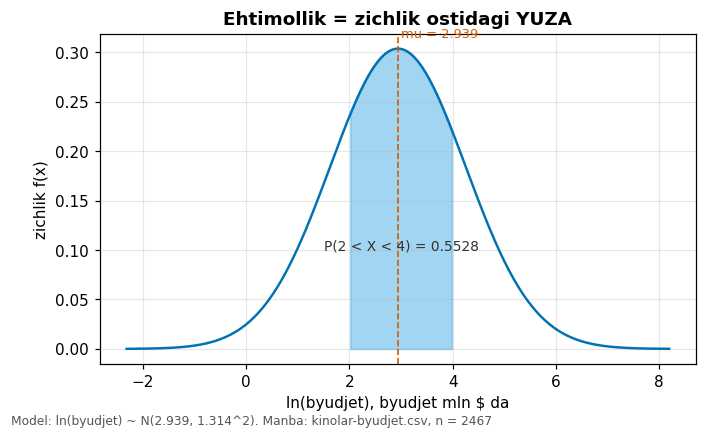

In [9]:
# --- 6-qadam: yuzani KOʻRSATISH ---------------------------------------
gx = np.linspace(mu-4*sig, mu+4*sig, 600)
gy = f_norm(gx)
fig, ax = plt.subplots(figsize=(7, 3.9))
m = (gx >= 2) & (gx <= 4)
ax.fill_between(gx[m], gy[m], color=oiSky, alpha=0.55)
ax.plot(gx, gy, color=oiBlue, lw=1.6)
ax.axvline(mu, color=oiVerm, ls="--", lw=1.1)
ax.text(3.0, 0.10, "P(2 < X < 4) = 0.5528", color="#333333", ha="center", fontsize=9)
ax.text(mu+0.06, 0.315, "mu = 2.939", color=oiVerm, fontsize=8.5)
ax.set_title("Ehtimollik = zichlik ostidagi YUZA", fontweight="bold")
ax.set_xlabel("ln(byudjet), byudjet mln $ da"); ax.set_ylabel("zichlik f(x)")
fig.text(0.01, -0.03, "Model: ln(byudjet) ~ N(2.939, 1.314^2). "
                      "Manba: kinolar-byudjet.csv, n = 2467", fontsize=8, color="#555555")
plt.show()

### Natija (kutilayotgan)

```
f(x)       = 1/(b-a)      = 0.066667
E[X]       = (a+b)/2      = 17.5000
Var(X)     = (b-a)^2/12   = 18.7500
SD(X)      = sqrt(Var)    = 4.3301
P(12<X<18) = (18-12)/(b-a)= 0.400000
F(18)      = (18-a)/(b-a) = 0.533333
P(X=15)    = 0            = 0.000000
integral f = 1.0000000000
|integral - 1| < 1e-10   : TRUE

ln(byudjet): mu = 2.938942   sigma = 1.314131
maks |qolda - dnorm| < 1e-15 : TRUE
barcha f(x) >= 0             : TRUE

aniq qiymat Phi(6)-Phi(-6)   = 0.9999999980
       n        qadam h     orta nuqta     trapetsiya  |orta - aniq|
      10     1.57695668   0.9999977722   1.0000022202      2.226e-06
     100     0.15769567   0.9999999981   0.9999999979      4.315e-11
    1000     0.01576957   0.9999999980   0.9999999980      4.375e-13
   10000     0.00157696   0.9999999980   0.9999999980        < 1e-13
integrate(-Inf, Inf): |I - 1| < 1e-8 : TRUE

NUQTA EHTIMOLI: x0 = 3 atrofidagi oraliq
 yarim eni d   P(3-d < X < 3+d)           P / (2d)
     0.50000       0.2961059902       0.2961059902
     0.05000       0.0303178378       0.3031783778
     0.00500       0.0030325064       0.3032506408
     0.00050       0.0003032514       0.3032513636
     0.00005       0.0000303251       0.3032513708
zichlik f(3) = 0.3032513709  <- limit shu songa intiladi
f(3) EHTIMOLLIK EMAS; f(3) > 0.3 ammo P(X=3) = 0

P(2 < lnB < 4) uch yol bilan:
  (i)   Phi farqi          = 0.5528282770
  (ii)  sonli integrallash = 0.5528282770
  (iii) tor panjara (20000)= 0.5528282771
  uchalasi 1e-9 aniqlikda mos : TRUE
  haqiqiy ulush (maʼlumotda)  = 0.5626266721
```

### Talqin — daftaringizga yozing

**T1.1** $n=10$ da panjara xatosi $2{,}2\times 10^{-6}$, $n=1000$ da
$4{,}4\times 10^{-13}$. Qadam $100$ marta kichrayganda xato necha marta
kichraydi? Oʻrta nuqta usuli uchun nazariy tartib $O(h^2)$ — sonlaringiz
buni tasdiqlaydimi?

**T1.2** $\Pr(3-\delta<X<3+\delta)$ nolga intiladi, ammo
$\Pr/(2\delta)$ **nolga intilmaydi** — u $0{,}30325$ ga intiladi.
Bu son nima? Uni zichlik taʼrifi bilan bogʻlang va bir jumlada
tushuntiring: *nima uchun $f(3)>0$ boʻlsa ham $\Pr(X=3)=0$*.

**T1.3** $f(3)=0{,}3033$. Talaba: «Demak byudjeti $e^3\approx 20$ mln \$
boʻlgan film uchrash ehtimoli $30\,\%$». Bu jumlada **ikkita** xato bor.
Ikkalasini ham nomlang.

**T1.4** Model $\Pr(2<\ln B<4)=0{,}5528$ deydi, maʼlumotda esa ulush
$0{,}5626$. Farq $0{,}0098$, yaʼni $\approx 1$ protsentil punkti. Bu
farq **katta**mi? Javobingizni $2\,467$ ta kuzatuv soni bilan bogʻlang.

**T1.5** Diskret holda $\Pr(X<4)\ne\Pr(X\le 4)$ edi (4-haftada farq
$0{,}2370$). Uzluksiz holda farq aynan nol. Qaysi *matematik* xossa bu
farqni yoʻqotdi? Bir jumlada ayting.

### Qaror

Kinoteatr $\Unif(10,25)$ taqsimotidagi kutish vaqtiga ega navbat
tizimini boshqaradi. Menejer: «$18$ daqiqadan koʻp kutgan mijozga
chegirma beramiz». **Chegirma olish ehtimolini** hisoblang va bir yilda
$40\,000$ mijoz uchun chegirmalar sonini baholang. Soʻng menejerga
aytilishi kerak boʻlgan **bitta ehtiyot jumlani** yozing: bu hisob
qanday farazga tayanadi va faraz buzilsa nima oʻzgaradi?

---

# 2-topshiriq. Normal ehtimolliklar: ikki yoʻnalishda

**Qiyinlik: 3 (Amaliy) · Blum: Qoʻllash · 20 ball · 20 daqiqa**

### Statistik tushuncha

$X\sim\Norm(\mu,\sigma^2)$ boʻlsa, **standartlashtirish**
$$Z=\frac{X-\mu}{\sigma}\sim\Norm(0,1)$$
har qanday normal taqsimotni **bitta** jadvalga keltiradi.
$z$ — kuzatuvning oʻrtachadan necha **standart ogʻish** uzoqligini
oʻlchaydigan **oʻlchovsiz** son.

Ikki yoʻnalish bir-biriga teskari:

| Yoʻnalish | Savol | Python funksiyasi |
|---|---|---|
| oldinga | qiymat berilgan → ehtimollik | `stats.norm.cdf(x, mu, sigma)` |
| orqaga | ehtimollik berilgan → qiymat | `stats.norm.ppf(p, mu, sigma)` |

**68–95–99,7 qoidasi** — taxminiy. Aniq qiymatlar
$0{,}682689$, $0{,}954500$, $0{,}997300$. Aniqlik talab qilinadigan
joyda (kvantil, ishonch oraligʻi) taxminiy son ishlatilmaydi.

### Maʼlumot

`kinolar-byudjet.csv`, model $\ln B\sim\Norm(2{,}938942;\,1{,}314131^2)$.

In [10]:
# --- 1-qadam: standart normal jadvalni OʻZIMIZ chiqaramiz --------------
print("%10s %14s %14s" % ("z","Phi(z)","1 - Phi(z)"))
for z in (-2.58,-1.96,-1.645,-1,0,0.5,1,1.645,1.96,2.58):
    print("%10.3f %14.6f %14.6f" % (z, Phi(z), 1-Phi(z)))

# --- 68-95-99,7: TAXMINIY va ANIQ -------------------------------------
print("\n%10s %16s %16s" % ("k","P(mu+-k sigma)","taxminiy qoida"))
for k, nom in zip((1,2,3), ("0.68","0.95","0.997")):
    print("%10d %16.6f %16s" % (k, Phi(k)-Phi(-k), nom))

# --- Teskari yoʻnalish: kritik qiymatlar -------------------------------
print("\n%10s %16s" % ("ishonch","z"))
for pc in (0.90, 0.95, 0.99):
    print("%10.2f %16.6f" % (pc, iPhi(1-(1-pc)/2)))

         z         Phi(z)     1 - Phi(z)
    -2.580       0.004940       0.995060
    -1.960       0.024998       0.975002
    -1.645       0.049985       0.950015
    -1.000       0.158655       0.841345
     0.000       0.500000       0.500000
     0.500       0.691462       0.308538
     1.000       0.841345       0.158655
     1.645       0.950015       0.049985
     1.960       0.975002       0.024998
     2.580       0.995060       0.004940

         k   P(mu+-k sigma)   taxminiy qoida
         1         0.682689             0.68
         2         0.954500             0.95
         3         0.997300            0.997

   ishonch                z
      0.90         1.644854
      0.95         1.959964
      0.99         2.575829


In [11]:
# --- 2-qadam: ikki funksiya bir-birining teskarisimi? ------------------
# iPhi(Phi(z)) = z boʻlishi SHART. Bu — «oldinga va orqaga» gʻoyasini
# sonli tasdiqlash.
print("\nOLDINGA VA ORQAGA: qnorm(pnorm(z)) = z ?")
print("%10s %14s %14s %14s" % ("p","z = qnorm(p)","pnorm(z)","|farq|<1e-12"))
for pp in (0.01,0.05,0.25,0.50,0.75,0.95,0.99):
    zz = iPhi(pp)
    print("%10.2f %14.6f %14.6f %14s" % (pp, zz, Phi(zz), tf(abs(Phi(zz)-pp) < 1e-12)))


OLDINGA VA ORQAGA: qnorm(pnorm(z)) = z ?
         p   z = qnorm(p)       pnorm(z)   |farq|<1e-12
      0.01      -2.326348       0.010000           TRUE
      0.05      -1.644854       0.050000           TRUE
      0.25      -0.674490       0.250000           TRUE
      0.50       0.000000       0.500000           TRUE
      0.75       0.674490       0.750000           TRUE
      0.95       1.644854       0.950000           TRUE
      0.99       2.326348       0.990000           TRUE


In [12]:
# --- 3-qadam: OLDINGA — haqiqiy byudjetlar uchun z va protsentil -------
# Har bir qatorda model nima deydi va maʼlumot nima deydi — YONMA-YON.
print("\nHAQIQIY BYUDJETLAR (model: lnB ~ N(%.6f, %.6f^2))" % (mu, sig))
print("%12s %12s %12s %14s %14s %12s"
      % ("byudjet","ln(byudjet)","z","model %-il","haqiqiy %-il","farq (p.p.)"))
for v in (5,10,20,22,35.805,50,75,100,125,150):
    z  = (np.log(v)-mu)/sig
    md = 100*Phi(z)                     # model protsentili
    hq = 100*np.mean(byudjet <= v)      # haqiqiy (empirik) protsentil
    print("%12.3f %12.4f %12.4f %14.1f %14.1f %12.1f" % (v, np.log(v), z, md, hq, md-hq))


HAQIQIY BYUDJETLAR (model: lnB ~ N(2.938942, 1.314131^2))
     byudjet  ln(byudjet)            z     model %-il   haqiqiy %-il  farq (p.p.)
       5.000       1.6094      -1.0117           15.6           16.7         -1.1
      10.000       2.3026      -0.4842           31.4           28.7          2.8
      20.000       2.9957       0.0432           51.7           48.9          2.8
      22.000       3.0910       0.1157           54.6           50.7          3.9
      35.805       3.5781       0.4864           68.7           66.1          2.6
      50.000       3.9120       0.7405           77.0           76.5          0.6
      75.000       4.3175       1.0490           85.3           86.5         -1.2
     100.000       4.6052       1.2679           89.8           92.6         -2.9
     125.000       4.8283       1.4377           92.5           95.3         -2.9
     150.000       5.0106       1.5765           94.3           98.5         -4.2


In [13]:
# --- 4-qadam: ORQAGA — protsentildan byudjetga -------------------------
# Bu yoʻnalish amaliyotda muhimroq: «yuqori 5 % qanday byudjetdan
# boshlanadi?» degan savol aynan shu.
print("\nTESKARI YONALISH: model boyicha protsentillar")
print("%10s %12s %16s %16s %14s" % ("protsentil","z","ln(byudjet)","model byudjet","haqiqiy"))
for pp in (0.50,0.75,0.90,0.95,0.99):
    z = iPhi(pp)
    print("%10.2f %12.6f %16.6f %16.3f %14.3f"
          % (pp, z, mu+z*sig, np.exp(mu+z*sig),
             np.quantile(byudjet, pp, method="linear")))
i95 = np.exp(mu + np.array([-1, 1])*iPhi(0.975)*sig)
print("\nMarkaziy 95%%: model [%.3f ; %.3f] mln $" % (i95[0], i95[1]))
print("bu oraliqqa tushgan haqiqiy filmlar ulushi = %.6f"
      % np.mean((byudjet > i95[0]) & (byudjet < i95[1])))


TESKARI YONALISH: model boyicha protsentillar
protsentil            z      ln(byudjet)    model byudjet        haqiqiy
      0.50     0.000000         2.938942           18.896         22.000
      0.75     0.674490         3.825309           45.847         50.000
      0.90     1.281552         4.623068          101.806         90.000
      0.95     1.644854         5.100494          164.103        125.000
      0.99     2.326348         5.996067          401.845        160.000

Markaziy 95%: model [1.438 ; 248.288] mln $
bu oraliqqa tushgan haqiqiy filmlar ulushi = 0.948520


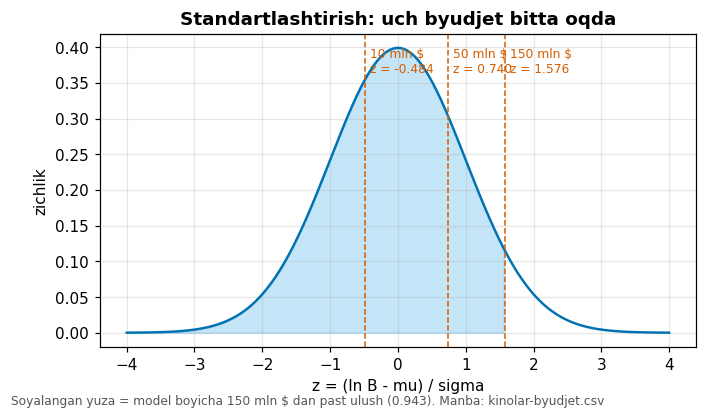

In [14]:
# --- 5-qadam: uchta byudjetni standart normal oʻqida koʻrsatish --------
bs = np.array([10.0, 50.0, 150.0])
zs = (np.log(bs)-mu)/sig
gx = np.linspace(-4, 4, 500); gy = stats.norm.pdf(gx)
fig, ax = plt.subplots(figsize=(7, 3.7))
ax.fill_between(gx[gx <= zs[2]], gy[gx <= zs[2]], color=oiSky, alpha=0.35)
ax.plot(gx, gy, color=oiBlue, lw=1.6)
for bb, zz in zip(bs, zs):
    ax.axvline(zz, color=oiVerm, ls="--", lw=1.0)
    ax.text(zz+0.07, 0.40, "%d mln $\nz = %.3f" % (bb, zz),
            color=oiVerm, fontsize=8, va="top")
ax.set_title("Standartlashtirish: uch byudjet bitta oqda", fontweight="bold")
ax.set_xlabel("z = (ln B - mu) / sigma"); ax.set_ylabel("zichlik")
fig.text(0.01, -0.03, "Soyalangan yuza = model boyicha 150 mln $ dan past ulush "
                      "(0.943). Manba: kinolar-byudjet.csv", fontsize=8, color="#555555")
plt.show()

### Natija (kutilayotgan)

```
         z         Phi(z)     1 - Phi(z)
    -2.580       0.004940       0.995060
    -1.960       0.024998       0.975002
    -1.645       0.049985       0.950015
    -1.000       0.158655       0.841345
     0.000       0.500000       0.500000
     0.500       0.691462       0.308538
     1.000       0.841345       0.158655
     1.645       0.950015       0.049985
     1.960       0.975002       0.024998
     2.580       0.995060       0.004940

         k   P(mu+-k sigma)   taxminiy qoida
         1         0.682689             0.68
         2         0.954500             0.95
         3         0.997300            0.997

   ishonch                z
      0.90         1.644854
      0.95         1.959964
      0.99         2.575829

OLDINGA VA ORQAGA: qnorm(pnorm(z)) = z ?
         p   z = qnorm(p)       pnorm(z)   |farq|<1e-12
      0.01      -2.326348       0.010000           TRUE
      0.05      -1.644854       0.050000           TRUE
      0.25      -0.674490       0.250000           TRUE
      0.50       0.000000       0.500000           TRUE
      0.75       0.674490       0.750000           TRUE
      0.95       1.644854       0.950000           TRUE
      0.99       2.326348       0.990000           TRUE

HAQIQIY BYUDJETLAR (model: lnB ~ N(2.938942, 1.314131^2))
     byudjet  ln(byudjet)            z     model %-il   haqiqiy %-il  farq (p.p.)
       5.000       1.6094      -1.0117           15.6           16.7         -1.1
      10.000       2.3026      -0.4842           31.4           28.7          2.8
      20.000       2.9957       0.0432           51.7           48.9          2.8
      22.000       3.0910       0.1157           54.6           50.7          3.9
      35.805       3.5781       0.4864           68.7           66.1          2.6
      50.000       3.9120       0.7405           77.0           76.5          0.6
      75.000       4.3175       1.0490           85.3           86.5         -1.2
     100.000       4.6052       1.2679           89.8           92.6         -2.9
     125.000       4.8283       1.4377           92.5           95.3         -2.9
     150.000       5.0106       1.5765           94.3           98.5         -4.2

TESKARI YONALISH: model boyicha protsentillar
protsentil            z      ln(byudjet)    model byudjet        haqiqiy
      0.50     0.000000         2.938942           18.896         22.000
      0.75     0.674490         3.825309           45.847         50.000
      0.90     1.281552         4.623068          101.806         90.000
      0.95     1.644854         5.100494          164.103        125.000
      0.99     2.326348         5.996067          401.845        160.000

Markaziy 95%: model [1.438 ; 248.288] mln $
bu oraliqqa tushgan haqiqiy filmlar ulushi = 0.948520
```

### Talqin — daftaringizga yozing

**T2.1** $50$ mln \$ da model va maʼlumot $0{,}6$ protsentil punkti
farq qiladi; $150$ mln \$ da farq $4{,}2$ punkt. Ikkalasi ham **bitta**
model. Bir jumlada ayting: model qayerda ishonchli, qayerda emas?

**T2.2** Teskari yoʻnalishdagi jadvalga qarang. $50$-protsentilda model
$18{,}90$ mln \$ beradi (haqiqiy $22$), $99$-protsentilda esa
$401{,}85$ (haqiqiy $160$). Nisbiy xatoni ikkala qator uchun hisoblang.
Qaysi biri kattaroq — va **nima uchun aynan shu qator qaror uchun
muhim**?

**T2.3** «Markaziy $95\,\%$» oraligʻining pastki chegarasi $1{,}44$ mln \$.
Toʻplamdagi eng arzon film $0{,}25$ mln \$. Model shu oraliqda nechta
filmni «kutadi» va haqiqatda nechtasi bor? Ikkala tomonni ham
tekshiring.

**T2.4** $z$ oʻlchovsiz son. Bu **nima uchun foydali**? Hosildorlik
(t/ga) va byudjet (mln \$) ni bir xil shkalada taqqoslash misolini
keltiring.

**T2.5** $\Phi(-1{,}96)=0{,}024998$, $0{,}025$ emas. $1{,}96$ oʻrniga
aniq $1{,}959964$ ni ishlatish qachon **ahamiyatsiz**, qachon
**ahamiyatli**? Bittadan misol keltiring.

### Qaror

Bank filmlarni moliyalashtiradi va **bitta loyihaga limit** belgilashi
kerak: arizalarning $95\,\%$ i limitdan past boʻlsin. Model
$164{,}10$ mln \$ deydi, maʼlumot $125{,}00$ mln \$ deydi. Qaysi birini
tanlaysiz? Javobingizda ikkala xatoning **narxini** ayting: limit juda
past boʻlsa nima yoʻqoladi, juda yuqori boʻlsa nima yoʻqoladi.

---

# 3-topshiriq. Q--Q grafik: bitta son yetarli emas

**Qiyinlik: 4 (Analitik) · Blum: Tahlil · 25 ball · 25 daqiqa**

### Statistik tushuncha

**Q--Q grafik** *(quantile--quantile plot)* — kuzatilgan tartib
statistikalarini nazariy normal kvantillarga qarshi chizadi. Agar
maʼlumot normal boʻlsa, nuqtalar **toʻgʻri chiziqda** yotadi.

Nazariy kvantillar **chizish nuqtalari** orqali olinadi. Biz Filliben
yaqinlashishini ishlatamiz (maʼruzada va Python kutubxonalarida
ishlatiladigan konventsiya):
$$m_i=\frac{i-0{,}3175}{n+0{,}365}\ (1<i<n),\qquad
m_n=0{,}5^{1/n},\qquad m_1=1-m_n,$$
soʻng nazariy kvantil $q_i=\Phi^{-1}(m_i)$.

Bugun **uchta** oʻlchovni yonma-yon qoʻyamiz:

| Oʻlchov | Nimani oʻlchaydi | Zaifligi |
|---|---|---|
| Qiyshiqlik | assimetriya | ikki choʻqqini **koʻrmaydi** |
| Q--Q korrelyatsiyasi $r$ | toʻgʻri chiziqqa yaqinlik | markazdagi nuqtalar hukmron |
| Shapiro--Wilk $p$ | rasmiy test | $n$ katta boʻlsa **har doim** rad etadi |

### Maʼlumot

`markaziy-osiyo-hosildorlik.csv` — toʻrtta seriya ($n=27$);
`kinolar-byudjet.csv` — ikkita seriya ($n=2\,467$).

In [15]:
# --- 1-qadam: uchta oʻlchov asbobini QOʻLDA yozamiz --------------------
# Qiyshiqlik: tuzatilgan Fisher–Pearson koeffitsiyenti G1 (1-haftadagi
# taʼrif; scipy.stats.skew(bias=False) bilan bir xil).
def qiyshiqlik(v):
    v = np.asarray(v, float); n = len(v); m = v.mean()
    g1 = (((v-m)**3).sum()/n)/((((v-m)**2).sum()/n)**1.5)
    return np.sqrt(n*(n-1))/(n-2)*g1
# Filliben chizish nuqtalari
def filliben(n):
    m = np.empty(n); m[n-1] = 0.5**(1/n); m[0] = 1-m[n-1]
    if n > 2:
        i = np.arange(2, n); m[i-1] = (i-0.3175)/(n+0.365)
    return m
# Q–Q korrelyatsiyasi: saralangan maʼlumot va nazariy kvantil orasida
def qq_r(v):
    s = np.sort(np.asarray(v, float))
    return np.corrcoef(s, iPhi(filliben(len(s))))[0, 1]

In [16]:
# --- 2-qadam: oltita seriya, uchta hukm --------------------------------
def seriya(nom, v):
    v = np.asarray(v, float); sw = stats.shapiro(v)
    pstr = ("%.3e" % sw.pvalue) if sw.pvalue < 0.001 else ("%.4f" % sw.pvalue)
    print("%-22s %6d %9.4f %9.4f %10.4f %9.4f %9.4f %11s"
          % (nom, len(v), v.mean(), v.std(ddof=1), qiyshiqlik(v), qq_r(v),
             sw.statistic, pstr))
# Mamlakat nomlarini POZITSIYA boʻyicha olamiz (lokal tuzogʻi yoʻq).
bug = lambda i: hosil.loc[hosil.mamlakat == mamlakatlar[i-1], "bugdoy"].to_numpy()
kar = lambda i: hosil.loc[hosil.mamlakat == mamlakatlar[i-1], "kartoshka"].to_numpy()

print("%-22s %6s %9s %9s %10s %9s %9s %11s"
      % ("seriya","n","xbar","s","qiyshiqlik","Q-Q r","SW W","SW p"))
seriya("UZ bugdoy", bug(1)); seriya("KG bugdoy", bug(2)); seriya("KZ bugdoy", bug(3))
seriya("UZ kartoshka", kar(1)); seriya("byudjet (mln $)", byudjet); seriya("ln(byudjet)", ln_b)

print("\nUZ va KG bugdoy qiyshiqligi farqi = %.4f (deyarli teng)"
      % abs(qiyshiqlik(bug(1))-qiyshiqlik(bug(2))))
print("ammo Q-Q r farqi = %.4f, SW p: %.4f va %.4f"
      % (qq_r(bug(2))-qq_r(bug(1)), stats.shapiro(bug(1)).pvalue,
         stats.shapiro(bug(2)).pvalue))

print("\n68% qoidasi tekshiruvi (xbar +- s ichidagi ulush; normal: 0.682689)")
for nm in (1, 2):
    v = bug(nm); ins = np.abs(v-v.mean()) < v.std(ddof=1)
    nom = mamlakatlar[nm-1]; nom = nom + " "*(16-len(nom))
    print("  %s %d/%d = %.4f" % (nom, ins.sum(), len(v), ins.mean()))

seriya                      n      xbar         s qiyshiqlik     Q-Q r      SW W        SW p


UZ bugdoy                  27    3.6048    1.1795    -0.6489    0.9405    0.8663      0.0025
KG bugdoy                  27    2.2347    0.2774    -0.6546    0.9660    0.9286      0.0640
KZ bugdoy                  27    1.0267    0.2599     0.0525    0.9869    0.9773      0.7979
UZ kartoshka               27   20.2377    8.4159     0.3998    0.9739    0.9313      0.0743
byudjet (mln $)          2467   35.8050   37.4124     1.6178    0.9007    0.8109   4.457e-47
ln(byudjet)              2467    2.9389    1.3141    -0.7375    0.9799    0.9597   1.228e-25

UZ va KG bugdoy qiyshiqligi farqi = 0.0056 (deyarli teng)
ammo Q-Q r farqi = 0.0255, SW p: 0.0025 va 0.0640

68% qoidasi tekshiruvi (xbar +- s ichidagi ulush; normal: 0.682689)
  Oʻzbekiston      18/27 = 0.6667
  Qirgʻiziston     20/27 = 0.7407


In [17]:
# --- 3-qadam: MINSTD generatori (2–4-haftadan oʻzgarishsiz) ------------
# x_{k+1} = (48271 x_k) mod 2147483647 ;  u_k = x_k / 2147483647
# R ning set.seed() va Pythonning default_rng() TURLI sonlar beradi,
# shu sababli ikkala daftar ham generatorni OʻZI yozadi.
def minstd_yangi(urugh):
    m, aa = 2147483647, 48271
    st = {"x": urugh % m or 1}
    def gen(k):
        u = np.empty(k)
        for i in range(k):
            st["x"] = (aa*st["x"]) % m
            u[i] = st["x"]/m
        return u
    return gen
print("\nMINSTD nazorat qiymatlari (urug 2026):")
for i, u in enumerate(minstd_yangi(2026)(5), 1):
    print("u[%d] = %.10f" % (i, u))

# Qaytarishsiz tanlash (4-haftadagi rad etish usuli bilan bir xil)
def tanla_k(u, ptr, N, k):
    olingan = []
    while len(olingan) < k:
        j = int(u[ptr]*N); ptr += 1
        if j not in olingan:
            olingan.append(j)
    return np.array(olingan), ptr


MINSTD nazorat qiymatlari (urug 2026):
u[1] = 0.0455402984
u[2] = 0.2757419647
u[3] = 0.3403783731
u[4] = 0.4044473546
u[5] = 0.0782521903


In [18]:
# --- 4-qadam: SHAPIRO–WILK NIMAGA BOGʻLIQ? -----------------------------
# AYNI BIR maʼlumotdan turli hajmdagi tanlanmalar olamiz. Maʼlumotning
# shakli oʻzgarmaydi — faqat n oʻzgaradi. p ga nima boʻlishini kuzating.
print("\nSHAPIRO-WILK VA TANLANMA HAJMI (ayni bir ln(byudjet) maʼlumoti)")
print("%8s %10s %12s %12s" % ("k","Q-Q r","SW W","SW p"))
g = minstd_yangi(2026); uu = g(200000); ptr = 0
for k in (20, 50, 200, 1000):
    idx, ptr = tanla_k(uu, ptr, len(ln_b), k)
    v = ln_b[idx]; sw = stats.shapiro(v)
    pstr = ("%.3e" % sw.pvalue) if sw.pvalue < 0.001 else ("%.4f" % sw.pvalue)
    print("%8d %10.4f %12.4f %12s" % (k, qq_r(v), sw.statistic, pstr))
sw_full = stats.shapiro(ln_b)
print("%8d %10.4f %12.4f %12.3e" % (len(ln_b), qq_r(ln_b), sw_full.statistic, sw_full.pvalue))


SHAPIRO-WILK VA TANLANMA HAJMI (ayni bir ln(byudjet) maʼlumoti)
       k      Q-Q r         SW W         SW p
      20     0.9652       0.9300       0.1542
      50     0.9757       0.9467       0.0249
     200     0.9807       0.9600    2.002e-05
    1000     0.9786       0.9569    1.419e-16
    2467     0.9799       0.9597    1.228e-25


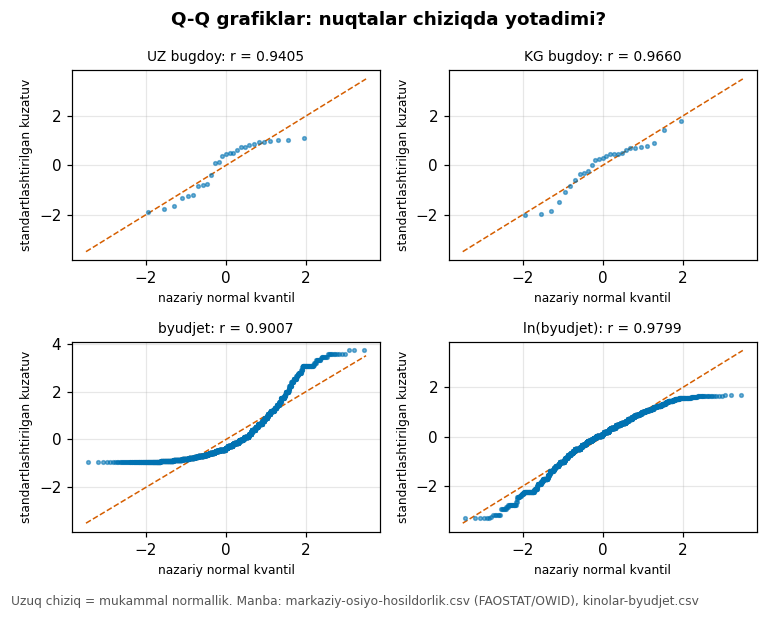

In [19]:
# --- 5-qadam: Q–Q grafiklarni QOʻLDA quramiz ---------------------------
def qq_nuqta(v):
    s = np.sort(np.asarray(v, float))
    return iPhi(filliben(len(s))), (s-s.mean())/s.std(ddof=1)
panel = [(bug(1), "UZ bugdoy: r = %.4f" % qq_r(bug(1))),
         (bug(2), "KG bugdoy: r = %.4f" % qq_r(bug(2))),
         (byudjet, "byudjet: r = %.4f" % qq_r(byudjet)),
         (ln_b, "ln(byudjet): r = %.4f" % qq_r(ln_b))]
fig, axs = plt.subplots(2, 2, figsize=(7, 5.4))
for ax, (v, nom) in zip(axs.ravel(), panel):
    tq, ob = qq_nuqta(v)
    ax.plot([-3.5, 3.5], [-3.5, 3.5], color=oiVerm, ls="--", lw=1.0)
    ax.plot(tq, ob, "o", color=oiBlue, ms=2.4, alpha=0.55)
    ax.set_title(nom, fontsize=9)
    ax.set_xlabel("nazariy normal kvantil", fontsize=8)
    ax.set_ylabel("standartlashtirilgan kuzatuv", fontsize=8)
fig.suptitle("Q-Q grafiklar: nuqtalar chiziqda yotadimi?", fontweight="bold")
fig.tight_layout()
fig.text(0.01, -0.02, "Uzuq chiziq = mukammal normallik. Manba: "
                      "markaziy-osiyo-hosildorlik.csv (FAOSTAT/OWID), kinolar-byudjet.csv",
         fontsize=8, color="#555555")
plt.show()

### Natija (kutilayotgan)

```
seriya                      n      xbar         s qiyshiqlik     Q-Q r      SW W        SW p
UZ bugdoy                  27    3.6048    1.1795    -0.6489    0.9405    0.8663      0.0025
KG bugdoy                  27    2.2347    0.2774    -0.6546    0.9660    0.9286      0.0640
KZ bugdoy                  27    1.0267    0.2599     0.0525    0.9869    0.9773      0.7979
UZ kartoshka               27   20.2377    8.4159     0.3998    0.9739    0.9313      0.0743
byudjet (mln $)          2467   35.8050   37.4124     1.6178    0.9007    0.8109   4.457e-47
ln(byudjet)              2467    2.9389    1.3141    -0.7375    0.9799    0.9597   1.228e-25

UZ va KG bugdoy qiyshiqligi farqi = 0.0056 (deyarli teng)
ammo Q-Q r farqi = 0.0255, SW p: 0.0025 va 0.0640

68% qoidasi tekshiruvi (xbar +- s ichidagi ulush; normal: 0.682689)
  Oʻzbekiston      18/27 = 0.6667
  Qirgʻiziston     20/27 = 0.7407

MINSTD nazorat qiymatlari (urug 2026):
u[1] = 0.0455402984
u[2] = 0.2757419647
u[3] = 0.3403783731
u[4] = 0.4044473546
u[5] = 0.0782521903

SHAPIRO-WILK VA TANLANMA HAJMI (ayni bir ln(byudjet) maʼlumoti)
       k      Q-Q r         SW W         SW p
      20     0.9652       0.9300       0.1542
      50     0.9757       0.9467       0.0249
     200     0.9807       0.9600    2.002e-05
    1000     0.9786       0.9569    1.419e-16
    2467     0.9799       0.9597    1.228e-25
```

### Talqin — daftaringizga yozing

**T3.1 (haftaning markaziy topilmasi).** Oʻzbekiston va Qirgʻiziston
bugʻdoyining qiyshiqligi $-0{,}6489$ va $-0{,}6546$ — farq $0{,}0056$,
yaʼni **deyarli aynan bir xil**. Ammo Shapiro--Wilk biri uchun
$p=0{,}0025$ (rad etadi), ikkinchisi uchun $p=0{,}0640$ (rad etmaydi)
beradi. Q--Q grafiklarga qarang va farqni **soʻz bilan** tushuntiring:
qiyshiqlik **nimani koʻrmaydi**?

**T3.2** $\ln(\text{byudjet})$ uchun $r=0{,}9799$ («aʼlo»), ammo
$p=1{,}2\times10^{-25}$ («qatʼiy rad etiladi»). Ikkalasi ham toʻgʻri
hisoblangan. 4-qadam jadvaliga qarang: $k=20$ da $p=0{,}1542$,
$k=2\,467$ da $p=1{,}2\times10^{-25}$ — **ayni bir maʼlumotdan**.
Nima oʻzgardi va nima oʻzgarmadi? Xulosangizni bir jumlada yozing.

**T3.3** Qozogʻiston bugʻdoyi uchun uchala oʻlchov ham «normal» deydi
($|{\text{qiyshiqlik}}|=0{,}05$, $r=0{,}9869$, $p=0{,}80$). Bu
Qozogʻiston hosildorligi **haqiqatan normal taqsimlangan** degani
emas. Nima uchun? ($n=27$ ekanini eslang.)

**T3.4** Oʻzbekistonda $\bar x\pm s$ oraligʻiga $18/27=0{,}6667$
kuzatuv tushdi — normal qiymat $0{,}6827$ ga juda yaqin. Ammo bu
seriya normal **emas**. Demak $68\,\%$ tekshiruvi qanday xatoga yoʻl
qoʻyadi?

**T3.5** Uchala vositani qanday **tartibda** ishlatish kerak? Oʻz
tavsiyangizni uchta qadam sifatida yozing va har biriga sabab
keltiring.

### Qaror

Sugʻurta kompaniyasi hosildorlik boʻyicha mahsulot ishlab chiqmoqda va
sizdan «Oʻzbekiston bugʻdoy hosildorligi normal taqsimlanganmi?» degan
savolga **bitta jumlali** javob soʻraydi. Javobingizni yozing —
va unga **ikkinchi jumla** qoʻshing: modelni baribir ishlatish kerak
boʻlsa, qaysi qismida ishonch bilan, qaysi qismida ehtiyot bilan
foydalaniladi.

---

# 4-topshiriq. Logarifmik almashtirish: nima yaxshilanadi, nima buziladi

**Qiyinlik: 4 (Analitik) · Blum: Baholash · 20 ball · 20 daqiqa**

### Statistik tushuncha

Oʻngga qiyshiq, musbat maʼlumot uchun $\ln$ almashtirish odatiy
vosita: koʻpaytiruvchi tuzilishni qoʻshiluvchiga aylantiradi va
katta qiymatlarni «siqadi».

**Ammo uchta chegara bor:**

1. $\ln$ faqat $x>0$ uchun aniqlangan;
2. u **haddan ortiq tuzatishi** mumkin — qiyshiqlik ishorasi
   almashadi;
3. teskari almashtirish $\exp(\bar{y})$ **oʻrtachani emas, medianani**
   baholaydi (Jensen tengsizligi).

Va eng muhimi: almashtirish **normallikni kafolatlamaydi**. U faqat
bitta nuqsonni (oʻngga qiyshiqlikni) tuzatadi.

### Maʼlumot

`kinolar-byudjet.csv` (byudjet va $\ln$ byudjet) hamda taqqoslash
uchun `markaziy-osiyo-hosildorlik.csv` dan Oʻzbekiston bugʻdoyi.

In [20]:
# --- 1-qadam: almashtirishdan oldin va keyin ---------------------------
print("%-26s %12s %12s" % ("korsatkich","byudjet","ln(byudjet)"))
print("%-26s %12.4f %12.4f" % ("xbar", byudjet.mean(), ln_b.mean()))
print("%-26s %12.4f %12.4f" % ("median", np.median(byudjet), np.median(ln_b)))
print("%-26s %12.4f %12.4f" % ("s", byudjet.std(ddof=1), ln_b.std(ddof=1)))
print("%-26s %12.4f %12.4f" % ("qiyshiqlik", qiyshiqlik(byudjet), qiyshiqlik(ln_b)))
print("%-26s %12.4f %12.4f" % ("Q-Q r", qq_r(byudjet), qq_r(ln_b)))
print("%-26s %12.4f %12.4f" % ("(xbar-median)/s",
      (byudjet.mean()-np.median(byudjet))/byudjet.std(ddof=1),
      (ln_b.mean()-np.median(ln_b))/ln_b.std(ddof=1)))
print("\nQiyshiqlik ONGDAN CHAPGA otdi: %+.4f -> %+.4f  (moduli %.4f -> %.4f)"
      % (qiyshiqlik(byudjet), qiyshiqlik(ln_b),
         abs(qiyshiqlik(byudjet)), abs(qiyshiqlik(ln_b))))

korsatkich                      byudjet  ln(byudjet)
xbar                            35.8050       2.9389
median                          22.0000       3.0910
s                               37.4124       1.3141
qiyshiqlik                       1.6178      -0.7375
Q-Q r                            0.9007       0.9799
(xbar-median)/s                  0.3690      -0.1157

Qiyshiqlik ONGDAN CHAPGA otdi: +1.6178 -> -0.7375  (moduli 1.6178 -> 0.7375)


In [21]:
# --- 2-qadam: empirik qoida log shkalada ------------------------------
print("\nEMPIRIK QOIDA ln shkalada (normal qiymat qavsda)")
for k in (1, 2, 3):
    print("  %d s ichida: %.4f   (%.4f)" % (k, np.mean(np.abs(ln_b-mu) < k*sig),
                                            Phi(k)-Phi(-k)))


EMPIRIK QOIDA ln shkalada (normal qiymat qavsda)
  1 s ichida: 0.6818   (0.6827)
  2 s ichida: 0.9493   (0.9545)
  3 s ichida: 0.9947   (0.9973)


In [22]:
# --- 3-qadam: TESKARI ALMASHTIRISH TUZOGʻI ----------------------------
print("\nTESKARI ALMASHTIRISH")
print("  exp(mean(ln B))   = %.4f mln $   <- MEDIANANI baholaydi, ortachani emas" % np.exp(mu))
print("  haqiqiy median    = %.4f mln $" % np.median(byudjet))
print("  haqiqiy ortacha   = %.4f mln $" % byudjet.mean())
print("  exp(mu + s^2/2)   = %.4f mln $   <- lognormal ortacha formulasi" % np.exp(mu+sig**2/2))


TESKARI ALMASHTIRISH
  exp(mean(ln B))   = 18.8958 mln $   <- MEDIANANI baholaydi, ortachani emas
  haqiqiy median    = 22.0000 mln $
  haqiqiy ortacha   = 35.8050 mln $
  exp(mu + s^2/2)   = 44.8091 mln $   <- lognormal ortacha formulasi


In [23]:
# --- 4-qadam: LOGARIFM HAR DOIM YORDAM BERADIMI? ----------------------
# Chapga qiyshiq maʼlumotga qoʻllab koʻramiz.
print("\nLOGARIFM HAR DOIM YORDAM BERADIMI? (UZ bugdoy hosildorligi)")
uzb = bug(1); l_uzb = np.log(uzb)
print("%-14s %12s %12s" % ("","xom","log"))
print("%-14s %12.4f %12.4f" % ("qiyshiqlik", qiyshiqlik(uzb), qiyshiqlik(l_uzb)))
print("%-14s %12.4f %12.4f" % ("Q-Q r", qq_r(uzb), qq_r(l_uzb)))
print("%-14s %12.4f %12.4f" % ("SW W", stats.shapiro(uzb).statistic,
                               stats.shapiro(l_uzb).statistic))
print("%-14s %12.4f %12.4f" % ("SW p", stats.shapiro(uzb).pvalue,
                               stats.shapiro(l_uzb).pvalue))
print("XULOSA: chapga qiyshiq maʼlumotda logarifm holatni YOMONLASHTIRDI.")


LOGARIFM HAR DOIM YORDAM BERADIMI? (UZ bugdoy hosildorligi)
                        xom          log
qiyshiqlik          -0.6489      -1.0121
Q-Q r                0.9405       0.9180
SW W                 0.8663       0.8309
SW p                 0.0025       0.0005
XULOSA: chapga qiyshiq maʼlumotda logarifm holatni YOMONLASHTIRDI.


In [24]:
# --- 5-qadam: MARKAZ VA QUYRUQ — nisbiy xato ---------------------------
print("\nMARKAZ VA QUYRUQ: model kvantili haqiqiy kvantilga nisbatan")
print("%10s %14s %14s %12s" % ("protsentil","model (mln $)","haqiqiy","nisbiy xato"))
for pp in (0.25,0.50,0.75,0.90,0.95,0.99):
    md = np.exp(mu+iPhi(pp)*sig)
    hq = np.quantile(byudjet, pp, method="linear")
    print("%10.2f %14.3f %14.3f %11.1f%%" % (pp, md, hq, 100*(md-hq)/hq))
print("Nisbiy xato markazda ~10%%, 99-protsentilda %.0f%% ga chiqadi."
      % (100*(np.exp(mu+iPhi(0.99)*sig)-np.quantile(byudjet, 0.99, method="linear"))
         / np.quantile(byudjet, 0.99, method="linear")))


MARKAZ VA QUYRUQ: model kvantili haqiqiy kvantilga nisbatan
protsentil  model (mln $)        haqiqiy  nisbiy xato
      0.25          7.788         10.000       -22.1%
      0.50         18.896         22.000       -14.1%
      0.75         45.847         50.000        -8.3%
      0.90        101.806         90.000        13.1%
      0.95        164.103        125.000        31.3%
      0.99        401.845        160.000       151.2%
Nisbiy xato markazda ~10%, 99-protsentilda 151% ga chiqadi.


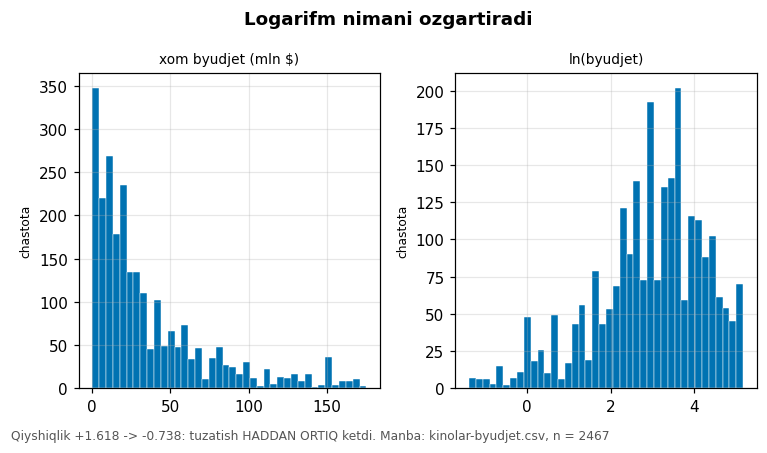

In [25]:
# --- 6-qadam: ikki shkalada gistogramma --------------------------------
fig, axs = plt.subplots(1, 2, figsize=(7, 3.9))
axs[0].hist(byudjet, bins=40, color=oiBlue, edgecolor="white", linewidth=0.3)
axs[0].set_title("xom byudjet (mln $)", fontsize=9)
axs[1].hist(ln_b, bins=40, color=oiBlue, edgecolor="white", linewidth=0.3)
axs[1].set_title("ln(byudjet)", fontsize=9)
for ax in axs: ax.set_ylabel("chastota", fontsize=8)
fig.suptitle("Logarifm nimani ozgartiradi", fontweight="bold")
fig.tight_layout()
fig.text(0.01, -0.02, "Qiyshiqlik +1.618 -> -0.738: tuzatish HADDAN ORTIQ ketdi. "
                      "Manba: kinolar-byudjet.csv, n = 2467", fontsize=8, color="#555555")
plt.show()

### Natija (kutilayotgan)

```
korsatkich                      byudjet  ln(byudjet)
xbar                            35.8050       2.9389
median                          22.0000       3.0910
s                               37.4124       1.3141
qiyshiqlik                       1.6178      -0.7375
Q-Q r                            0.9007       0.9799
(xbar-median)/s                  0.3690      -0.1157

Qiyshiqlik ONGDAN CHAPGA otdi: +1.6178 -> -0.7375  (moduli 1.6178 -> 0.7375)

EMPIRIK QOIDA ln shkalada (normal qiymat qavsda)
  1 s ichida: 0.6818   (0.6827)
  2 s ichida: 0.9493   (0.9545)
  3 s ichida: 0.9947   (0.9973)

TESKARI ALMASHTIRISH
  exp(mean(ln B))   = 18.8958 mln $   <- MEDIANANI baholaydi, ortachani emas
  haqiqiy median    = 22.0000 mln $
  haqiqiy ortacha   = 35.8050 mln $
  exp(mu + s^2/2)   = 44.8091 mln $   <- lognormal ortacha formulasi

LOGARIFM HAR DOIM YORDAM BERADIMI? (UZ bugdoy hosildorligi)
                        xom          log
qiyshiqlik          -0.6489      -1.0121
Q-Q r                0.9405       0.9180
SW W                 0.8663       0.8309
SW p                 0.0025       0.0005
XULOSA: chapga qiyshiq maʼlumotda logarifm holatni YOMONLASHTIRDI.

MARKAZ VA QUYRUQ: model kvantili haqiqiy kvantilga nisbatan
protsentil  model (mln $)        haqiqiy  nisbiy xato
      0.25          7.788         10.000       -22.1%
      0.50         18.896         22.000       -14.1%
      0.75         45.847         50.000        -8.3%
      0.90        101.806         90.000        13.1%
      0.95        164.103        125.000        31.3%
      0.99        401.845        160.000       151.2%
Nisbiy xato markazda ~10%, 99-protsentilda 151% ga chiqadi.
```

### Talqin — daftaringizga yozing

**T4.1** Q--Q korrelyatsiyasi $0{,}9007$ dan $0{,}9799$ ga koʻtarildi —
almashtirish **foyda berdi**. Ayni paytda qiyshiqlik $+1{,}6178$ dan
$-0{,}7375$ ga oʻtdi — almashtirish **haddan ortiq tuzatdi**. Ikkala
bayonot ham toʻgʻri. Bir jumlada ayting: $\ln$ almashtirish aslida
**nimani** kafolatlaydi va **nimani** kafolatlamaydi?

**T4.2** $\exp(\bar{y})=18{,}90$, haqiqiy median $22{,}00$, haqiqiy
oʻrtacha $35{,}81$. Nima uchun $\exp(\bar{y})$ oʻrtachadan **shunchalik**
uzoq? Va nima uchun u medianaga ham aynan teng emas?

**T4.3** Bugʻdoy hosildorligiga $\ln$ qoʻllash uchala oʻlchovni ham
yomonlashtirdi. Umumiy qoidani bir jumlada yozing: $\ln$ almashtirish
qanday maʼlumotga **mos**, qanday maʼlumotga **mos emas**?

**T4.4** Nisbiy xato $25$-protsentilda $-22{,}1\,\%$, $99$-protsentilda
$+151{,}2\,\%$. Ishora ham, kattalik ham oʻzgaradi. Bunday xatoni
**bitta son bilan** («model yaxshi/yomon») ifodalash mumkinmi? Javobni
asoslang.

**T4.5** Model $99$-protsentilni $401{,}85$ mln \$ deb baholaydi, ammo
toʻplamdagi **eng qimmat** film $175$ mln \$. Ikki mumkin boʻlgan
sababni yozing: biri modelning kamchiligi, ikkinchisi maʼlumotning
kamchiligi. Qaysi biri qaysi ekanini ayting.

### Qaror

Siz maslahatchisiz. Mijoz: «Byudjet maʼlumotini logarifmladim, endi u
normal — normal modelga asoslangan har qanday hisobni bemalol
ishlataveraman». **Uch jumlada** javob bering: (1) nima toʻgʻri,
(2) nima notoʻgʻri, (3) mijoz aynan qaysi hisobdan voz kechishi kerak.

---

# 5-topshiriq. Binomialning normal yaqinlashishi va uzluksizlik tuzatmasi

**Qiyinlik: 4 (Analitik) · Blum: Baholash · 25 ball · 25 daqiqa**

### Statistik tushuncha

$X\sim\Bin(n,p)$ da $n$ katta boʻlsa, ehtimolliklarni qoʻlda hisoblash
ogʻirlashadi. Normal yaqinlashish:
$$X\approx\Norm\bigl(np,\;np(1-p)\bigr),\qquad
\text{shart: } np\ge 10 \ \text{va}\ n(1-p)\ge 10 .$$

Ammo **diskret** miqdorni **uzluksiz** taqsimot bilan almashtirish
tizimli xato tugʻdiradi: $X=3$ diskret nuqtasi uzluksiz shkalada
$[2{,}5;\,3{,}5]$ oraligʻiga mos keladi. **Uzluksizlik tuzatmasi**
*(continuity correction)* aynan shu:
$$\Pr(a\le X\le b)\approx
\Phi\!\left(\frac{b+0{,}5-np}{\sqrt{np(1-p)}}\right)-
\Phi\!\left(\frac{a-0{,}5-np}{\sqrt{np(1-p)}}\right).$$

Bugun tuzatmaning **bahosini oʻlchaymiz**.

### Maʼlumot

4-haftadan: $p=0{,}452807$ — filmning R reyting olish ulushi
($1\,113/2\,458$). $X$ — tasodifiy tanlangan $n$ ta filmdagi R
reytinglilar soni.

In [26]:
# --- 1-qadam: uchta n uchun uch xil hisob ------------------------------
p = 0.452807
print("%5s %9s %9s %8s %8s %6s %12s %12s %12s %10s %10s"
      % ("n","mu=np","sigma","np","n(1-p)","shart","aniq binom","normal+UT","normal-UT",
         "xato+UT","xato-UT"))
for n in (10, 30, 100):
    m_ = n*p; s_ = np.sqrt(n*p*(1-p))
    lo_ = int(np.floor(m_-1)); hi_ = int(np.ceil(m_+1))      # mu atrofidagi oraliq
    ex = stats.binom.pmf(np.arange(lo_, hi_+1), n, p).sum()  # ANIQ qiymat
    ut = Phi((hi_+0.5-m_)/s_)-Phi((lo_-0.5-m_)/s_)           # tuzatma BILAN
    nu = Phi((hi_-m_)/s_)-Phi((lo_-m_)/s_)                   # tuzatmaSIZ
    print("%5d %9.4f %9.4f %8.2f %8.2f %6s %12.6f %12.6f %12.6f %10.6f %10.6f"
          % (n, m_, s_, n*p, n*(1-p), "HA" if (n*p >= 10 and n*(1-p) >= 10) else "YOQ",
             ex, ut, nu, abs(ut-ex), abs(nu-ex)))
print("\nOraliqlar: n=10 -> 3<=X<=6 ; n=30 -> 12<=X<=15 ; n=100 -> 44<=X<=47")

print("\nTUZATMA NECHA BAROBAR YAXSHILAYDI")
for n in (10, 30, 100):
    m_ = n*p; s_ = np.sqrt(n*p*(1-p))
    lo_ = int(np.floor(m_-1)); hi_ = int(np.ceil(m_+1))
    ex = stats.binom.pmf(np.arange(lo_, hi_+1), n, p).sum()
    ut = abs(Phi((hi_+0.5-m_)/s_)-Phi((lo_-0.5-m_)/s_)-ex)
    nu = abs(Phi((hi_-m_)/s_)-Phi((lo_-m_)/s_)-ex)
    print("  n = %3d : %.1f barobar" % (n, nu/ut))

    n     mu=np     sigma       np   n(1-p)  shart   aniq binom    normal+UT    normal-UT    xato+UT    xato-UT
   10    4.5281    1.5741     4.53     5.47    YOQ     0.798231     0.796051     0.659302   0.002180   0.138930
   30   13.5842    2.7264    13.58    16.42     HA     0.536146     0.536577     0.417623   0.000431   0.118523
  100   45.2807    4.9777    45.28    54.72     HA     0.311549     0.311877     0.236626   0.000328   0.074923

Oraliqlar: n=10 -> 3<=X<=6 ; n=30 -> 12<=X<=15 ; n=100 -> 44<=X<=47

TUZATMA NECHA BAROBAR YAXSHILAYDI
  n =  10 : 63.7 barobar
  n =  30 : 275.0 barobar
  n = 100 : 228.4 barobar


In [27]:
# --- 2-qadam: BITTA NUQTA ehtimoli ------------------------------------
# Tuzatmasiz normal model P(X = k) ni qanday hisoblaydi? Yuza nolga
# teng — chunki uzluksiz taqsimotda nuqta ehtimoli nol (1-topshiriq!).
print("\nBITTA NUQTA EHTIMOLI P(X = k), k = round(np)")
print("%5s %5s %14s %14s %14s" % ("n","k","aniq binom","normal+UT","normal-UT"))
for n in (10, 30, 100):
    m_ = n*p; s_ = np.sqrt(n*p*(1-p)); k_ = int(round(m_))
    print("%5d %5d %14.6f %14.6f %14.6f"
          % (n, k_, stats.binom.pmf(k_, n, p),
             Phi((k_+0.5-m_)/s_)-Phi((k_-0.5-m_)/s_), 0))
print("Tuzatmasiz normal model NUQTA ehtimolini har doim 0 deb beradi.")


BITTA NUQTA EHTIMOLI P(X = k), k = round(np)
    n     k     aniq binom      normal+UT      normal-UT
   10     5       0.235325       0.238648       0.000000
   30    14       0.143108       0.143847       0.000000
  100    45       0.079860       0.079885       0.000000
Tuzatmasiz normal model NUQTA ehtimolini har doim 0 deb beradi.


In [28]:
# --- 3-qadam: n OSHSA tuzatma keraksiz boʻladIMI? ----------------------
# Barcha k uchun eng katta farqni oʻlchaymiz (Kolmogorov masofasi).
print("\nMAKSIMAL XATO (barcha k uchun |F_binom(k) - F_normal(k)|)")
print("%6s %14s %14s %10s" % ("n","+UT","-UT","nisbat"))
for n in (10, 20, 30, 50, 100, 200, 500):
    m_ = n*p; s_ = np.sqrt(n*p*(1-p)); kk = np.arange(n+1)
    e1 = np.abs(stats.binom.cdf(kk, n, p)-Phi((kk+0.5-m_)/s_)).max()
    e0 = np.abs(stats.binom.cdf(kk, n, p)-Phi((kk-m_)/s_)).max()
    print("%6d %14.6f %14.6f %10.1f" % (n, e1, e0, e0/e1))


MAKSIMAL XATO (barcha k uchun |F_binom(k) - F_normal(k)|)
     n            +UT            -UT     nisbat
    10       0.004874       0.128476       26.4
    20       0.003038       0.091457       30.1
    30       0.002369       0.074885       31.6
    50       0.001822       0.058100       31.9
   100       0.001272       0.041303       32.5
   200       0.000895       0.029197       32.6
   500       0.000564       0.018482       32.8


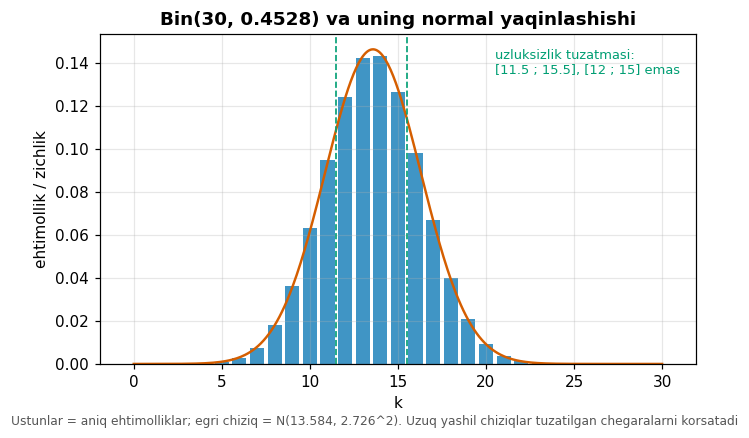

In [29]:
# --- 4-qadam: koʻrsatish ----------------------------------------------
n = 30; m_ = n*p; s_ = np.sqrt(n*p*(1-p))
kk = np.arange(n+1); pk = stats.binom.pmf(kk, n, p)
cx = np.linspace(0, n, 400)
fig, ax = plt.subplots(figsize=(7, 3.9))
ax.bar(kk, pk, width=0.8, color=oiBlue, alpha=0.75)
ax.plot(cx, stats.norm.pdf(cx, m_, s_), color=oiVerm, lw=1.6)
for xv in (11.5, 15.5):
    ax.axvline(xv, color=oiGreen, ls="--", lw=1.1)
ax.text(20.5, 0.135, "uzluksizlik tuzatmasi:\n[11.5 ; 15.5], [12 ; 15] emas",
        color=oiGreen, fontsize=8.5)
ax.set_title("Bin(30, 0.4528) va uning normal yaqinlashishi", fontweight="bold")
ax.set_xlabel("k"); ax.set_ylabel("ehtimollik / zichlik")
fig.text(0.01, -0.03, "Ustunlar = aniq ehtimolliklar; egri chiziq = N(13.584, 2.726^2). "
                      "Uzuq yashil chiziqlar tuzatilgan chegaralarni korsatadi",
         fontsize=8, color="#555555")
plt.show()

### Natija (kutilayotgan)

```
    n     mu=np     sigma       np   n(1-p)  shart   aniq binom    normal+UT    normal-UT    xato+UT    xato-UT
   10    4.5281    1.5741     4.53     5.47    YOQ     0.798231     0.796051     0.659302   0.002180   0.138930
   30   13.5842    2.7264    13.58    16.42     HA     0.536146     0.536577     0.417623   0.000431   0.118523
  100   45.2807    4.9777    45.28    54.72     HA     0.311549     0.311877     0.236626   0.000328   0.074923

Oraliqlar: n=10 -> 3<=X<=6 ; n=30 -> 12<=X<=15 ; n=100 -> 44<=X<=47

TUZATMA NECHA BAROBAR YAXSHILAYDI
  n =  10 : 63.7 barobar
  n =  30 : 275.0 barobar
  n = 100 : 228.4 barobar

BITTA NUQTA EHTIMOLI P(X = k), k = round(np)
    n     k     aniq binom      normal+UT      normal-UT
   10     5       0.235325       0.238648       0.000000
   30    14       0.143108       0.143847       0.000000
  100    45       0.079860       0.079885       0.000000
Tuzatmasiz normal model NUQTA ehtimolini har doim 0 deb beradi.

MAKSIMAL XATO (barcha k uchun |F_binom(k) - F_normal(k)|)
     n            +UT            -UT     nisbat
    10       0.004874       0.128476       26.4
    20       0.003038       0.091457       30.1
    30       0.002369       0.074885       31.6
    50       0.001822       0.058100       31.9
   100       0.001272       0.041303       32.5
   200       0.000895       0.029197       32.6
   500       0.000564       0.018482       32.8
```

### Talqin — daftaringizga yozing

**T5.1** $n=10$ da shart **bajarilmaydi** ($np=4{,}53<10$), ammo
tuzatma bilan xato atigi $0{,}0022$. Demak shart nimani kafolatlaydi
va nimani kafolatlamaydi? Ehtiyotkorlik bilan javob bering.

**T5.2** Tuzatmasiz xato $n=100$ da ham $0{,}0749$ — bu $7{,}5$
protsentil punkti. Maksimal xato jadvaliga qarang: $n$ $10$ dan $500$
gacha oshganda tuzatmasiz xato $0{,}1285$ dan $0{,}0185$ ga tushdi,
ammo nisbat $26$ dan $33$ ga **koʻtarildi**. Xulosa: $n$ ni oshirish
tuzatmaning oʻrnini bosadimi?

**T5.3** Tuzatmasiz normal model $\Pr(X=k)$ ni **aynan nol** deb
beradi. Bu 1-topshiriqdagi qaysi natijaning bevosita natijasi?
Bogʻlanishni bir jumlada yozing.

**T5.4** $n=10$ da tuzatma xatoni $63{,}7$ marta kamaytiradi,
$n=30$ da $275$ marta, $n=100$ da $228$ marta. Nisbat monoton emas.
Bu **tasodifmi** yoki tizimlimi? (Maslahat: aniq oraliq chegaralari
$\mu$ ga nisbatan turlicha joylashgan.)

**T5.5** Menejer: «$n=100$ katta son, shuning uchun normal
yaqinlashishni tuzatmasdan ishlatsak ham boʻladi». Uning fikrini
sonlar bilan rad eting va **bitta jumlalik** amaliy qoida taklif
qiling.

### Qaror

Kinoteatr har hafta $30$ ta film namoyish etadi va R reytingli
filmlar uchun $16$ ta seans ajratgan. **Seans yetishmay qolish
ehtimolini** ($\Pr(X\ge 17)$) uch usulda hisoblang: aniq binomial,
tuzatma bilan normal, tuzatmasiz normal. Uchta javobni bir yilda
($52$ hafta) necha marta muammo yuz berishiga aylantiring. Menejer
uchun qaysi farq **amaliy jihatdan** ahamiyatli — yozib bering.

---

# 6-topshiriq (ixtiyoriy, uyda). Koʻrsatkichli taqsimot va xotirasizlik

**Qiyinlik: 5 (Ilgʻor) · Blum: Yaratish · +5 bonus ball**

### Statistik tushuncha

Agar hodisalar soni $\Pois(\lambda)$ boʻlsa, **ketma-ket hodisalar
orasidagi vaqt** $\Expo(\lambda)$ boʻladi:
$$f(t)=\lambda e^{-\lambda t},\quad t>0;\qquad
F(t)=1-e^{-\lambda t};\qquad \E[T]=\SD(T)=\frac1\lambda .$$

**Xotirasizlik** *(memorylessness)*:
$\Pr(T>s+t\mid T>s)=\Pr(T>t)$ — kutgan vaqt keyingi kutishga
**taʼsir qilmaydi**. Bu — matematik xossa, tabiat qonuni emas.

In [30]:
lam = 10.9474    # 4-haftadan: yiliga Horror filmlari ~ Pois(lambda)
print("lambda = %.4f (4-hafta: yiliga Horror filmlari ~ Pois(lambda))" % lam)
print("E[T]   = 1/lambda = %.6f yil = %.2f kun" % (1/lam, 365/lam))
print("SD(T)  = 1/lambda = %.6f yil  (E = SD)" % (1/lam))
print("Median = ln2/lambda = %.6f yil = %.2f kun" % (np.log(2)/lam, 365*np.log(2)/lam))
print("P(T > E[T]) = e^-1 = %.6f" % np.exp(-1))

print("\nXOTIRASIZLIK: P(T > s+t | T > s) = P(T > t)?")
print("%8s %8s %16s %16s %8s" % ("s","t","P(T>s+t|T>s)","P(T>t)","mos"))
for s0 in (0.05, 0.10, 0.20):
    t0 = 0.05
    lhs = np.exp(-lam*(s0+t0))/np.exp(-lam*s0); rhs = np.exp(-lam*t0)
    print("%8.2f %8.2f %16.6f %16.6f %8s" % (s0, t0, lhs, rhs, tf(abs(lhs-rhs) < 1e-12)))

lambda = 10.9474 (4-hafta: yiliga Horror filmlari ~ Pois(lambda))
E[T]   = 1/lambda = 0.091346 yil = 33.34 kun
SD(T)  = 1/lambda = 0.091346 yil  (E = SD)
Median = ln2/lambda = 0.063316 yil = 23.11 kun
P(T > E[T]) = e^-1 = 0.367879

XOTIRASIZLIK: P(T > s+t | T > s) = P(T > t)?
       s        t     P(T>s+t|T>s)           P(T>t)      mos
    0.05     0.05         0.578469         0.578469     TRUE
    0.10     0.05         0.578469         0.578469     TRUE
    0.20     0.05         0.578469         0.578469     TRUE


### Natija (kutilayotgan)

```
lambda = 10.9474 (4-hafta: yiliga Horror filmlari ~ Pois(lambda))
E[T]   = 1/lambda = 0.091346 yil = 33.34 kun
SD(T)  = 1/lambda = 0.091346 yil  (E = SD)
Median = ln2/lambda = 0.063316 yil = 23.11 kun
P(T > E[T]) = e^-1 = 0.367879

XOTIRASIZLIK: P(T > s+t | T > s) = P(T > t)?
       s        t     P(T>s+t|T>s)           P(T>t)      mos
    0.05     0.05         0.578469         0.578469     TRUE
    0.10     0.05         0.578469         0.578469     TRUE
    0.20     0.05         0.578469         0.578469     TRUE
```

### Vazifa

1. Median ($23{,}11$ kun) oʻrtachadan ($33{,}34$ kun) **kichik**.
   Bu taqsimotning qaysi xossasini koʻrsatadi? $\Pr(T>\E[T])=0{,}3679$
   soni bilan bogʻlang.
2. Xotirasizlikni **isbotlang**: $\Pr(T>s+t\mid T>s)$ ni shartli
   ehtimollik taʼrifidan (3-hafta) keltirib chiqaring.
3. Xotirasizlik qaysi holatlarda **notoʻgʻri** faraz? Kamida uchta
   misol keltiring (biri texnikadan, biri insonlar xatti-harakatidan,
   biri iqtisodiyotdan) va har birida xossa **nima uchun** buzilishini
   ayting.
4. MINSTD bilan $10\,000$ ta $\Expo(\lambda)$ kutish vaqti
   generatsiya qiling (teskari almashtirish usuli:
   $T=-\ln(1-U)/\lambda$). Simulyatsiya oʻrtachasi, medianasi va
   $\Pr(T>\E[T])$ ni nazariy qiymatlar bilan solishtiring.
   **Urugʻ, generator nomi va takrorlar sonini yozing.**

---

# Yigʻma nazorat jadvali

Topshirishdan oldin natijalaringizni quyidagi qiymatlar bilan
solishtiring. **Bitta ham son farq qilmasligi kerak** — ikkala til
uchun ham.

| Koʻrsatkich | Qiymat | Qayerda |
|---|---|---|
| $\Unif(10,25)$: $\Pr(12<X<18)$ | 0.400000 | 1-topshiriq |
| $\ln B$ modeli: $\mu$ | 2.938942 | 1-topshiriq |
| $\ln B$ modeli: $\sigma$ | 1.314131 | 1-topshiriq |
| Panjara $n=1000$, xato | 4.375e-13 | 1-topshiriq |
| $f(3)$ (zichlik) | 0.3032513709 | 1-topshiriq |
| $\Pr(2<\ln B<4)$ model | 0.5528282770 | 1-topshiriq |
| $\Pr(2<\ln B<4)$ maʼlumot | 0.5626266721 | 1-topshiriq |
| $\Phi(1{,}96)$ | 0.975002 | 2-topshiriq |
| $\Pr(\mu\pm 1\sigma)$ | 0.682689 | 2-topshiriq |
| 95 % uchun aniq $z$ | 1.959964 | 2-topshiriq |
| 150 mln \$: model %-il | 94.3 | 2-topshiriq |
| 150 mln \$: haqiqiy %-il | 98.5 | 2-topshiriq |
| Model 99-protsentil | 401.845 | 2-topshiriq |
| Haqiqiy 99-protsentil | 160.000 | 2-topshiriq |
| UZ bugʻdoy: qiyshiqlik | −0.6489 | 3-topshiriq |
| KG bugʻdoy: qiyshiqlik | −0.6546 | 3-topshiriq |
| UZ bugʻdoy: Q--Q $r$ | 0.9405 | 3-topshiriq |
| KG bugʻdoy: Q--Q $r$ | 0.9660 | 3-topshiriq |
| UZ / KG Shapiro $p$ | 0.0025 / 0.0640 | 3-topshiriq |
| MINSTD $u_1$ | 0.0455402984 | 3-topshiriq |
| $\ln B$, $k=20$: SW $p$ | 0.1542 | 3-topshiriq |
| $\ln B$, $k=2467$: SW $p$ | 1.228e-25 | 3-topshiriq |
| Byudjet qiyshiqligi | +1.6178 | 4-topshiriq |
| $\ln$ byudjet qiyshiqligi | −0.7375 | 4-topshiriq |
| $\exp(\bar{y})$ | 18.8958 | 4-topshiriq |
| $n=10$: aniq binomial | 0.798231 | 5-topshiriq |
| $n=10$: normal $+$ tuzatma | 0.796051 | 5-topshiriq |
| $n=10$: normal $-$ tuzatma | 0.659302 | 5-topshiriq |
| $n=100$: tuzatmasiz xato | 0.074923 | 5-topshiriq |
| $\Expo$: $\E[T]$ (kun) | 33.34 | 6-topshiriq |
| Xotirasizlik qiymati | 0.578469 | 6-topshiriq |

**Agar sonlaringiz mos kelmasa.**
(1) Byudjetni **mln \$** ga aylantirdingizmi ($/10^6$)?
(2) Standart ogʻishda maxraj $n-1$ mi (`std(ddof=1)`)?
(3) Qiyshiqlikda **tuzatilgan** $G_1$ formulasini ishlatdingizmi?
(4) Q--Q da **Filliben** chizish nuqtalarini ishlatdingizmi?
    (`statsmodels` ning `ProbPlot` boshqa konventsiyani beradi va $r$
    ozgina farq qiladi — bu xato emas, ammo jadval bilan mos kelmaydi.)
(5) Uzluksizlik tuzatmasida $\pm 0{,}5$ **ikkala** chegaraga
    qoʻyilganmi?

---

# Topshirish tartibi va akademik halollik

* **Fayl:** bajarilgan `W05-lab-<familiya>.ipynb`, *yoki*
  `W05-lab-<familiya>.Rmd` + undan olingan `.html`.
* **Kod xatosiz ishlashi shart:** *Restart and Run All* dan soʻng
  hech bir katak xato bermasligi kerak.
* **Talqin va qaror** har bir topshiriq uchun matn koʻrinishida
  yozilgan boʻlishi shart.
* **Muddat:** laboratoriyadan keyingi 48 soat ichida, Moodle.
* **Grafiklar:** faqat Okabe--Ito ranglari; maʼnoni faqat rang bilan
  bermang; oʻq nomlari va manba koʻrsatilishi shart.
* **Simulyatsiya:** har bir natija yonida urugʻ (2026), generator nomi
  (MINSTD) va tanlanma hajmi.
* **Maʼlumot halolligi:** ikkala toʻplam ham **haqiqiy**; manbani
  koʻrsating. Mashq uchun son oʻylab topsangiz, uni
  *simulyatsiya qilingan maʼlumot* deb belgilang.

**Sunʼiy intellektdan foydalanish.** Mumkin: kod xatosini topish,
funksiya hujjatini tushuntirish, matnni tahrirlash. Mumkin emas:
talqin va qaror bosqichlarini SIʼ ga yozdirish — aynan shu qism
baholanadi.

> **Alohida ogohlantirish.** Til modellari uzluksiz taqsimotlarda
> muntazam ravishda: (i) zichlik qiymatini ehtimollik deb ataydi,
> (ii) bitta statistikaga qarab «maʼlumot normal» deb xulosa
> chiqaradi, (iii) normal modelni uzoq quyruqda ishonch bilan
> qoʻllaydi, (iv) uzluksizlik tuzatmasini tushirib qoldiradi,
> (v) «logarifm normallikni kafolatlaydi» deb yozadi. Bu haftaning
> SI topshirigʻi (`W05-si-topshiriqlari`) aynan shu besh xatoga
> bagʻishlangan.

**Deklaratsiya majburiy:** ish oxirida qaysi vosita, qaysi bosqichda,
qanday soʻrov bilan ishlatilgani va javob qanday tekshirilgani
yoziladi.

---

**Manbalar:** Newbold, Carlson & Thorne, *Statistics for Business and
Economics*, 5-bob · McClave & Sincich, *Statistics*, 5-bob ·
Heumann, Schomaker & Shalabh, *Introduction to Statistics and Data
Analysis*, 8-bob · Çetinkaya-Rundel & Hardin, *Introduction to Modern
Statistics* (Q--Q grafiklar va normal model) ·
Limpert, Stahel & Abbt (2001), *Log-normal distributions across the
sciences*, BioScience 51(5), 341--352 ·
Maʼlumot: FAOSTAT / Our World in Data (hosildorlik);
kinolar-byudjet.csv (2000--2018).